# A patent DUV objective: pupil, focal field and lithographic aerial image

**Use case:** form and analyze an image using the 193.368 nm, NA 1.2 immersion
objective from US7557996, at its stored 62 mm object field point. This notebook
includes the optical layout **and the resulting field and image**.

The optical prescription is imported with `vecdiff.IO`. The wavefront is a
committed ray-traced pupil dataset from
[wavec, commit dc74da5](https://github.com/blancusjh/wavec/blob/dc74da5ff9c283a0d7b4ef85febc8ead4288e2d3/vectorwave/data/duv.json).
The independent `references/projection.py` applies a sine-condition vector
pupil projection. It uses shared `ElectricSpectrum` for homogeneous Maxwell
propagation. **This is a pupil-based reference application, not the main
spectral method propagated through all 48 encounters.** The preceding notebook
provides a separate pattern image made from the main method's conic response.

Assumptions: one local field point, uniform entrance-pupil amplitude, supplied
wavefront phase, fixed refractive indices, a thin amplitude mask and a periodic
image cell. Mirror coating losses, pupil-dependent transmission and mask/resist
physics are absent. The prescription import alone does not supply these.

In [1]:
# Locate this checkout and initialize inline figures.

from pathlib import Path
import sys

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(root))
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map, fwhm

style()

## 1. Import and inspect the actual system and its pupil wavefront

The geometric prescription and the wavefront have different roles. The former
defines surfaces, media, stops and folds; the latter is the phase input to this
reference calculation. Only the stored field point is represented.
The wavefront map is in nm of optical path, and its piston-removed RMS is
measured over the unit pupil.

In [2]:
# ### Load the physical prescription and reference wavefront
#
# The prescription describes the real surfaces; the stored wavefront supplies
# the separate reference pupil phase used in this notebook.

In [3]:
import json
from scipy.interpolate import RegularGridInterpolator
from vecdiff.IO import read_prescription

system = read_prescription(root / "examples/data/US7557996.csv")
data = json.loads((root / "examples/data/duv_wavefront.json").read_text())

### Optical and pupil parameters

Keep image-side wavelength, numerical aperture, index, and grid explicit.

In [4]:
wavelength = data["wavelength_mm"] * 1e3  # µm
na = data["na_image"]
index = data["n_image"]
W = np.array(data["wavefront"]["values_waves"])
u = np.linspace(-1, 1, len(W))
U, V = np.meshgrid(u, u)
inside = U * U + V * V <= 1

### Interpolated reference phase

Use the stored grid to evaluate the aberrated pupil and its piston-removed RMS.

In [5]:
interpolator = RegularGridInterpolator((u, u), W, bounds_error=False, fill_value=0.0)


def wavefront(u, v):
    return interpolator(np.stack((v, u), axis=-1))


rms = np.std(W[inside]) * wavelength * 1e3

**Read the result:** The stored wavefront is a reference, not a propagation through 48 faces.

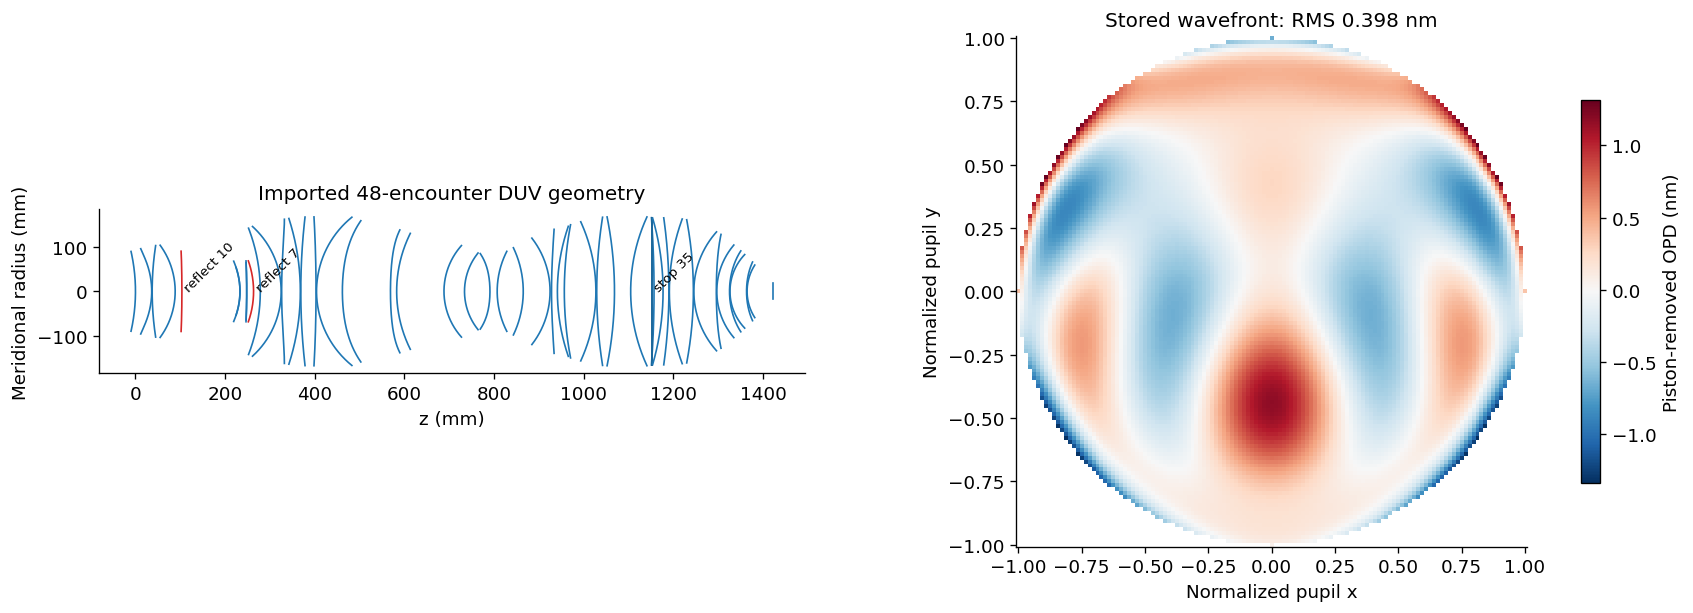

US7557996 hyper-NA DUV immersion objective; λ=193.368 nm, NA=1.2, n=1.59667693, reduction=4.0:1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

# Trace each encounter by physical surface type.
colors = {"refract": "tab:blue", "reflect": "tab:red", "stop": "black"}

for encounter in system.encounters:
    a = encounter.semidiameter

    if a is None:
        continue

    rr = np.linspace(-a, a, 201)
    surf = encounter.surface

    if hasattr(surf, "sag"):
        zz = surf.sag(abs(rr)) + surf.frame.origin[2]
    else:
        zz = np.full_like(rr, surf.frame.origin[2])

    axes[0].plot(zz, rr, color=colors[encounter.interaction], lw=1)

    if encounter.interaction in ["reflect", "stop"]:
        axes[0].annotate(
            f"{encounter.interaction} {encounter.number}",
            (zz[len(rr) // 2], 0),
            fontsize=8,
            rotation=45,
        )

axes[0].set(
    xlabel="z (mm)",
    ylabel="Meridional radius (mm)",
    title="Imported 48-encounter DUV geometry",
    aspect="equal",
)

# Show the stored wavefront separately from the prescription layout.
scalar_map(
    fig,
    axes[1],
    np.where(inside, (W - np.mean(W[inside])) * wavelength * 1e3, np.nan),
    u,
    u,
    f"Stored wavefront: RMS {rms:.3f} nm",
    xlabel="Normalized pupil x",
    ylabel="Normalized pupil y",
    label="Piston-removed OPD (nm)",
    vmin=None,
    cmap="RdBu_r",
)
axes[1].set_aspect("equal")
show(fig, "06_duv_layout_wavefront")
print(
    f"{data['name']}; λ={wavelength * 1e3:.3f} nm, NA={na}, n={index}, reduction={data['reduction']}:1"
)

# Check prescription count and stored focal parameters.
assert len(system.encounters) == 48 and np.isclose(
    system.wavelength, data["wavelength_mm"]
)

## 2. Construct the vector pupil and calculate the point response

For uniform entrance-pupil illumination, polarization follows the meridional
and sagittal ray bases. The Debye factor $\sqrt{\cos\theta}$ becomes
$1/\sqrt{\cos\theta}$ in Cartesian transverse spatial-frequency density because
$d k_x d k_y=k^2\sin\theta\cos\theta\,d\theta d\phi$.
The reference is defined by that convention; it does not infer Fresnel losses
from the prescription.

The same complex transfer function is used for the PSF, meridional propagation
and pattern imaging. This avoids showing an ideal PSF while imaging with a
different, aberrated transfer.

In [7]:
# Build a vector pupil transfer and its focal point-spread function.

from references.projection import pupil_transfer
from vecdiff import ElectricSpectrum, Medium
from examples.image_formation import (
    circuit_pattern,
    coherent_image,
    aerial_image,
    disk_sources,
)

count = 512
pixel = 0.012  # µm
x = (np.arange(count) - count // 2) * pixel
f = np.fft.fftfreq(count, d=pixel)
FX, FY = np.meshgrid(f, f)
transfer, k, used = pupil_transfer(
    FX, FY, wavelength=wavelength, na=na, index=index, wavefront=wavefront
)
psf = np.fft.fftshift(np.fft.ifft2(transfer, axes=(0, 1)), axes=(0, 1))
intensity = np.sum(abs(psf) ** 2, axis=-1)
peak = intensity.max()
mid = count // 2
spec = ElectricSpectrum(k[used], transfer[used] / count**2, wavelength, Medium(index))
# Evaluate a genuinely finer focal grid; do not smooth or interpolate coarse pixels.
focal_axis = np.linspace(-0.3, 0.3, 301)
PX, PY = np.meshgrid(focal_axis, focal_axis)
focal_e, _ = spec.evaluate(np.stack((PX, PY, 0 * PX), axis=-1), backend="nufft")
focal_norm = np.sum(abs(focal_e) ** 2, axis=-1)

**Read the result:** Read all vector PSF components against one stated scale.

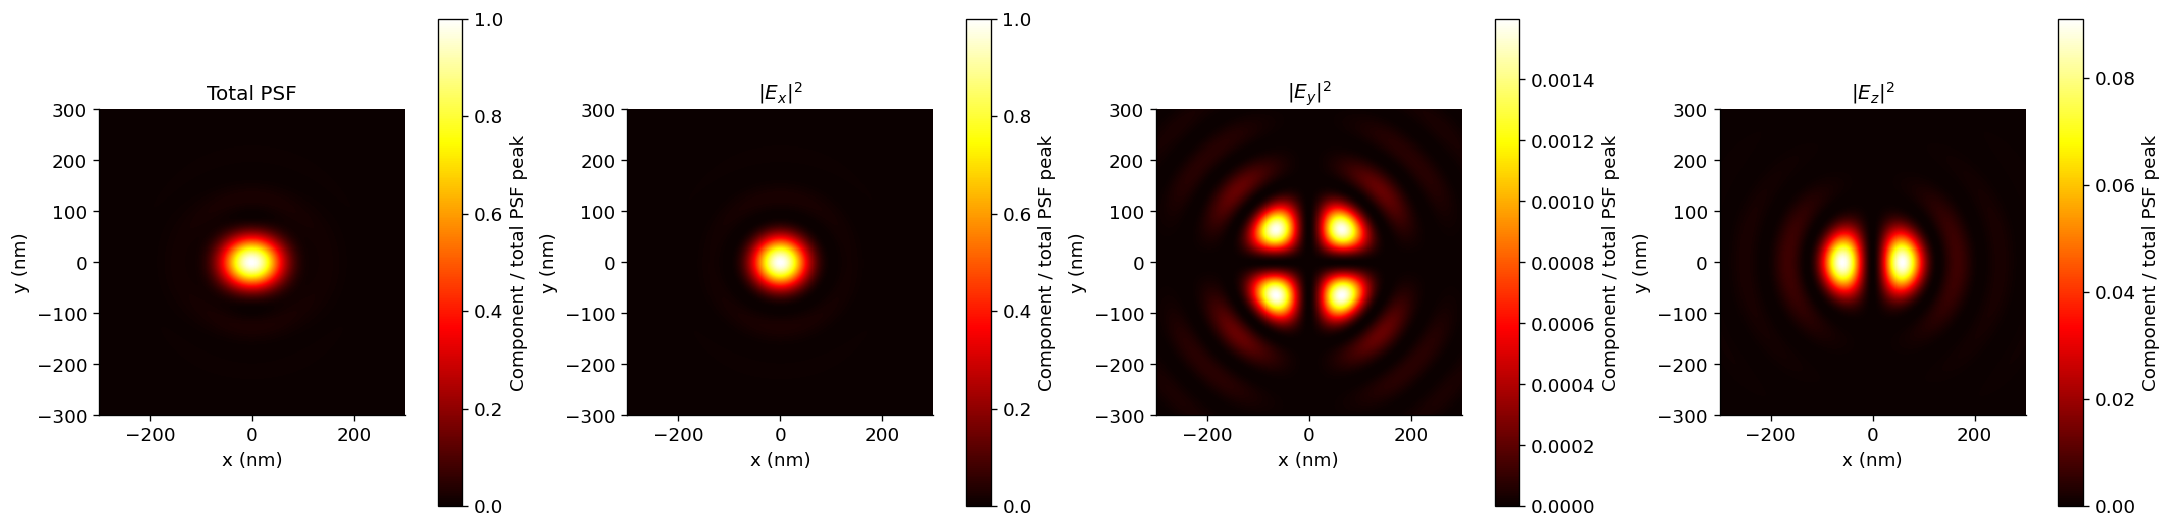

Focal FWHM: x 95.53 nm; y 80.30 nm
Longitudinal electric-norm fraction in full cell: 15.12%


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5.5), layout="constrained")

for j, ax in enumerate(axes):
    values = focal_norm if j == 0 else abs(focal_e[..., j - 1]) ** 2
    scalar_map(
        fig,
        ax,
        values / peak,
        focal_axis * 1e3,
        focal_axis * 1e3,
        ["Total PSF", r"$|E_x|^2$", r"$|E_y|^2$", r"$|E_z|^2$"][j],
        xlabel="x (nm)",
        ylabel="y (nm)",
        label="Component / total PSF peak",
    )
    ax.set(xlim=(-300, 300), ylim=(-300, 300), aspect="equal")

show(fig, "06_duv_vector_psf")
print(
    f"Focal FWHM: x {fwhm(x * 1e3, intensity[mid]):.2f} nm; y {fwhm(x * 1e3, intensity[:, mid]):.2f} nm"
)
print(
    f"Longitudinal electric-norm fraction in full cell: {np.sum(abs(psf[..., 2]) ** 2) / intensity.sum():.2%}"
)

## 3. Examine through-focus propagation and focal polarization

The homogeneous propagation below evaluates the vector `ElectricSpectrum`;
every populated mode satisfies $\mathbf k\cdot\mathbf E=0$ in the immersion
medium. The meridional map resolves the focal region in nanometres.
A polarization ellipse describes only the transverse pair $(E_x,E_y)$.

In [9]:
# Inspect the meridional field and transverse polarization near focus.

xx = np.linspace(-0.3, 0.3, 241)
dz = np.linspace(-0.8, 0.8, 321)
XM, Z = np.meshgrid(xx, dz)
e, h = spec.evaluate(np.stack((XM, 0 * XM, Z), axis=-1), backend="nufft")

**Read the result:** The meridional window and polarization describe distinct observables.

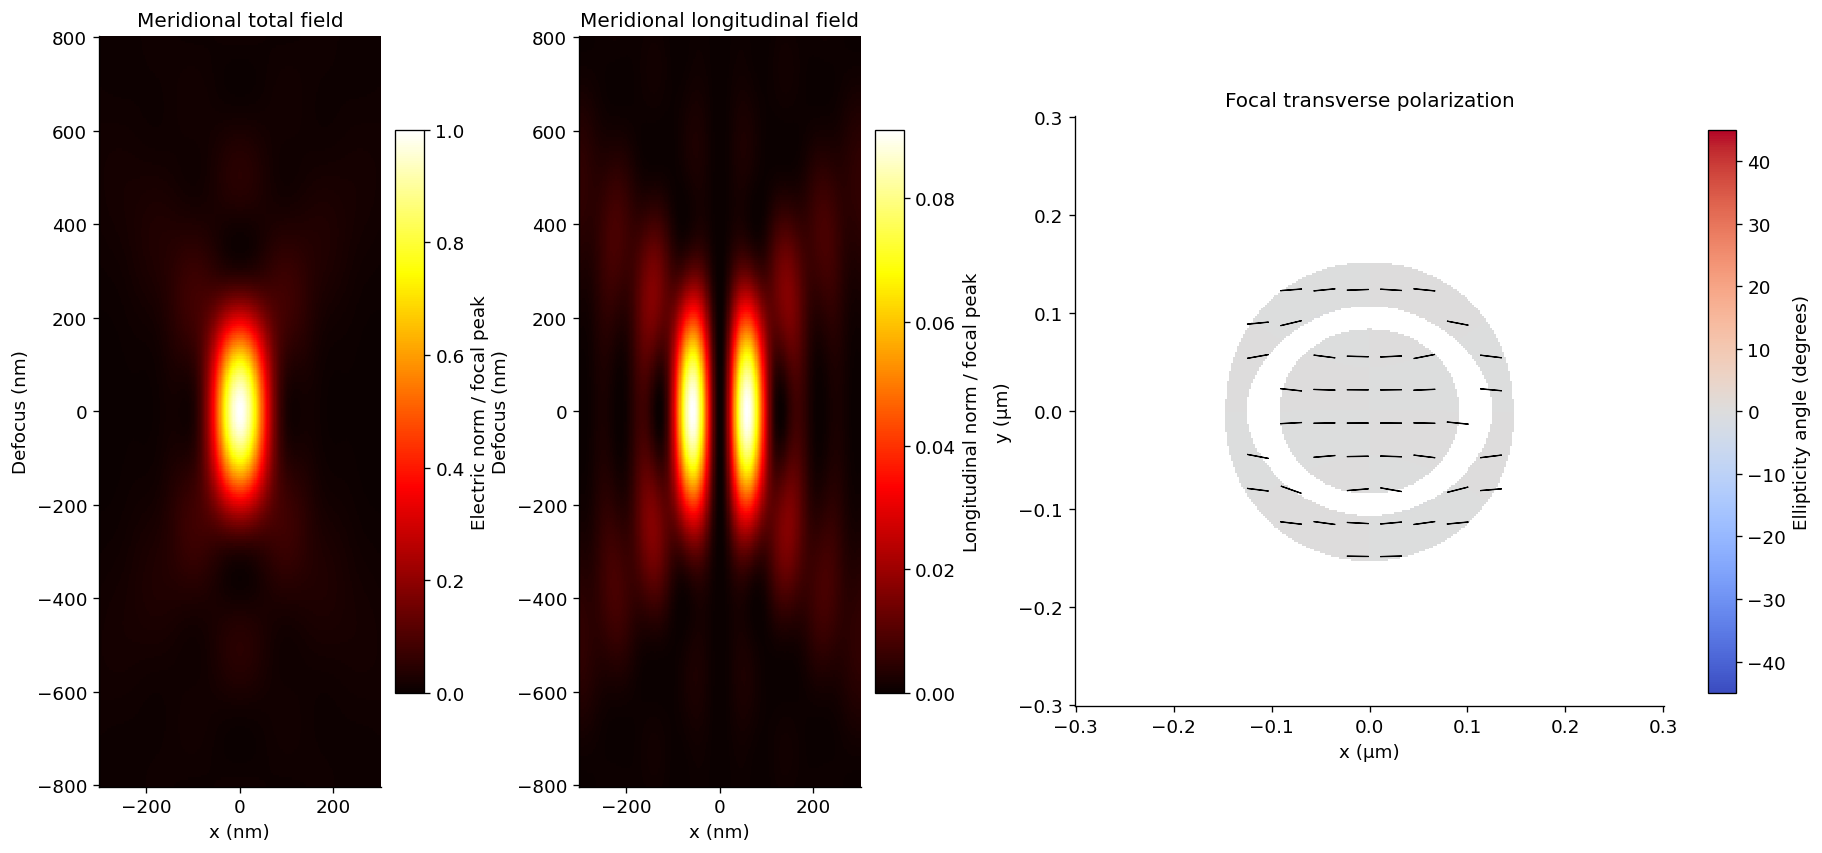

PSF FFT / direct spectrum relative E error: 2e-15


In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 7),
    gridspec_kw={"width_ratios": [1, 1, 2]},
    layout="constrained",
)
scalar_map(
    fig,
    axes[0],
    np.sum(abs(e) ** 2, axis=-1) / peak,
    xx * 1e3,
    dz * 1e3,
    "Meridional total field",
    xlabel="x (nm)",
    ylabel="Defocus (nm)",
    label="Electric norm / focal peak",
)
scalar_map(
    fig,
    axes[1],
    abs(e[..., 2]) ** 2 / peak,
    xx * 1e3,
    dz * 1e3,
    "Meridional longitudinal field",
    xlabel="x (nm)",
    ylabel="Defocus (nm)",
    label="Longitudinal norm / focal peak",
)
polarization_map(
    fig, axes[2], focal_e, focal_axis, focal_axis, title="Focal transverse polarization"
)
show(fig, "06_duv_meridional_polarization")
# Same field via FFT and continuous spectrum at held-out focal pixels.
ix = np.arange(mid - 12, mid + 13, 3)
iy = np.arange(mid - 12, mid + 13, 4)
IX, IY = np.meshgrid(ix, iy)
p = np.stack((x[IX], x[IY], np.zeros_like(IX)), axis=-1)
actual = spec.evaluate(p)[0]
expected = psf[IY, IX]
print(
    f"PSF FFT / direct spectrum relative E error: {np.linalg.norm(actual - expected) / np.linalg.norm(expected):.3g}"
)
assert np.allclose(actual, expected, rtol=1e-9, atol=1e-12)

## 4. Form a circuit-pattern image and separate its vector contributions

A 250 nm line/contact pattern is given at wafer scale. The image-plane cell is
6.144 µm wide. All source contributions use the stored wavefront and the same
vector transfer. The partial-coherence example samples a disk with
$\sigma=0.6$; source weights sum to one, so increasing source count does not
artificially increase illumination power.

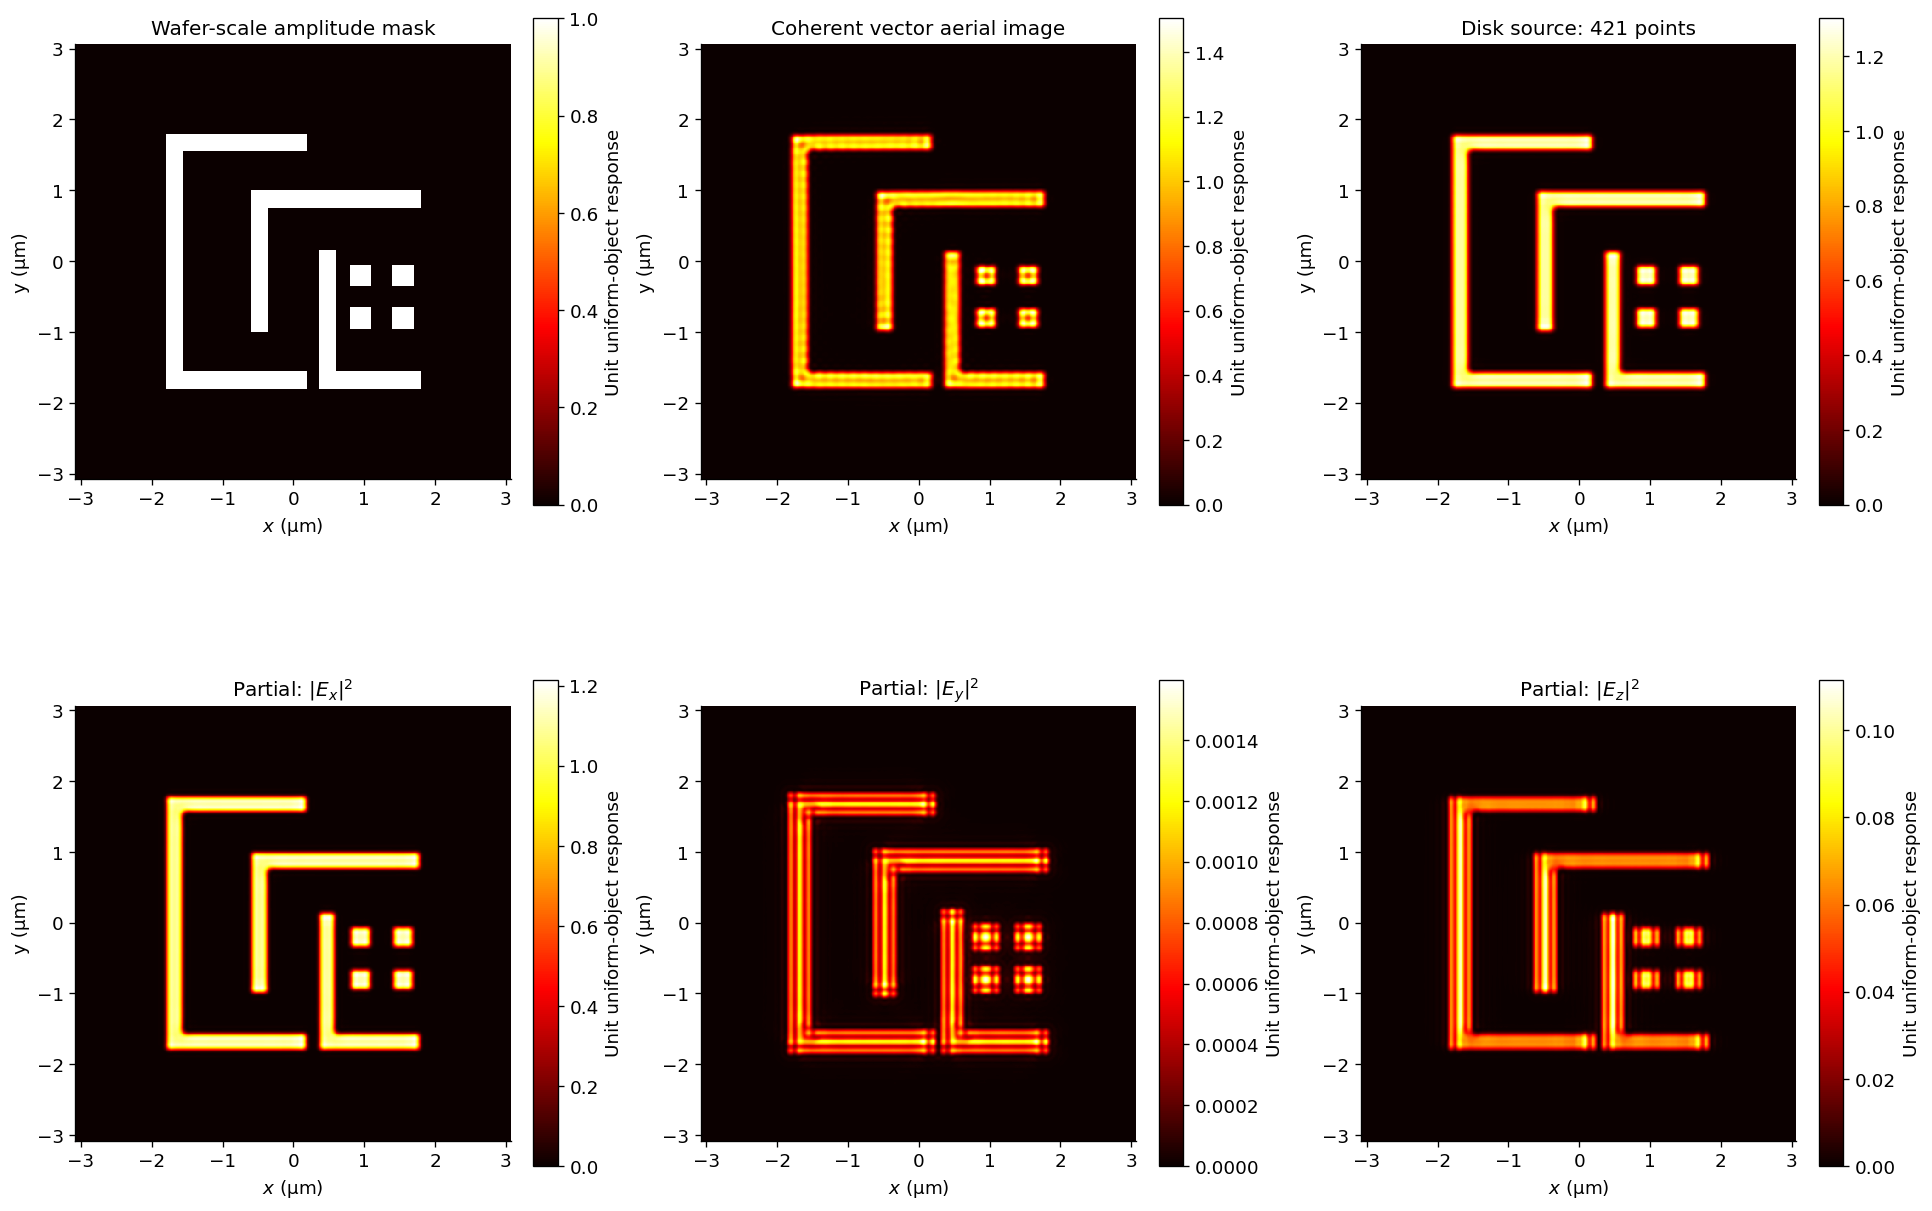

Partial-coherence longitudinal electric-norm fraction: 7.238%


In [11]:
# Convolve the circuit mask with the complex vector transfer.

mask = circuit_pattern(x)
coherent = coherent_image(mask, transfer)
sources = disk_sources(0.6 * na / wavelength * count * pixel, step=2)
partial = aerial_image(mask, transfer, sources)
fig, axes = plt.subplots(2, 3, figsize=(16, 11), layout="constrained")
values = [
    mask,
    np.sum(abs(coherent) ** 2, axis=-1),
    partial.sum(axis=-1),
    partial[..., 0],
    partial[..., 1],
    partial[..., 2],
]
titles = [
    "Wafer-scale amplitude mask",
    "Coherent vector aerial image",
    f"Disk source: {len(sources)} points",
    r"Partial: $|E_x|^2$",
    r"Partial: $|E_y|^2$",
    r"Partial: $|E_z|^2$",
]

for ax, im, title in zip(axes.flat, values, titles):
    scalar_map(
        fig, ax, im, x, x, title, ylabel="y (µm)", label="Unit uniform-object response"
    )
    ax.set_aspect("equal")

show(fig, "06_duv_circuit_image")
print(
    f"Partial-coherence longitudinal electric-norm fraction: {partial[..., 2].sum() / partial.sum():.3%}"
)

**Read the result:** Compare circuit lineouts after viewing the two-dimensional image.

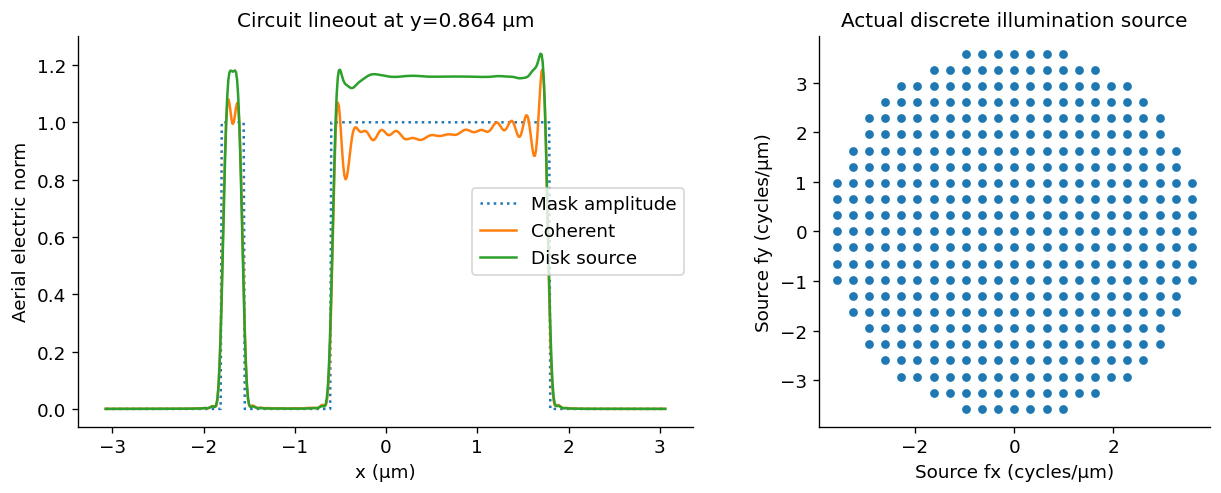

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
row = np.argmin(abs(x - 0.87))
axes[0].plot(x, mask[row], ":", label="Mask amplitude")
axes[0].plot(x, np.sum(abs(coherent[row]) ** 2, axis=-1), label="Coherent")
axes[0].plot(x, partial[row].sum(axis=-1), label="Disk source")
axes[0].set(
    xlabel="x (µm)",
    ylabel="Aerial electric norm",
    title=f"Circuit lineout at y={x[row]:.3f} µm",
)
axes[0].legend()
axes[1].scatter(sources[:, 0] / (count * pixel), sources[:, 1] / (count * pixel), s=18)
axes[1].set(
    xlabel="Source fx (cycles/µm)",
    ylabel="Source fy (cycles/µm)",
    title="Actual discrete illumination source",
    aspect="equal",
)
show(fig, "06_duv_lineout_source")

## 5. Quantify TE/TM resolution with commensurate line gratings

For lines parallel to $y$, TE is input $E_y$ and TM is input $E_x$.
Each grating has an integer number of periods in the cell. We use the analytic
Fourier coefficients of a 50% duty amplitude grating; this avoids changing duty
cycle as the pitch crosses the pixel grid. Contrast is measured on a complete
periodic line profile: $C=(I_{max}-I_{min})/(I_{max}+I_{min})$.

The scalar comparison has the same pupil support and wavefront, with unit
scalar transfer amplitude. It is a defined scalar approximation, not another
Maxwell solution.

In [13]:
# Compare TE/TM grating contrast, source sampling, and image pixels.

ty, _, _ = pupil_transfer(
    FX,
    FY,
    wavelength=wavelength,
    na=na,
    index=index,
    polarization=(0, 1),
    wavefront=wavefront,
)
scalar = (
    used
    * np.exp(
        2j
        * np.pi
        * wavefront(
            np.where(used, FX * wavelength / na, 0),
            np.where(used, FY * wavelength / na, 0),
        )
    )
)[..., None]
period = count * pixel
period_counts = np.arange(20, 57, 2)
half_pitches = period / (2 * period_counts)

**Next step:** Compute contrast from the vector transfer before plotting it.

In [14]:
def grating_contrast(periods, tf, sources):
    # Fourier coefficients for a centered 50% duty grating; DC transmission 1/2.
    M = np.zeros(count, complex)
    M[0] = count / 2

    for harmonic in range(1, count // (2 * periods) + 1, 2):
        value = count * np.sin(np.pi * harmonic / 2) / (np.pi * harmonic)
        M[(harmonic * periods) % count] = value
        M[(-harmonic * periods) % count] = value

    profile = np.zeros(count)

    for sx, sy in sources:
        field = np.fft.ifft(np.roll(M, int(sx))[:, None] * tf[int(sy) % count], axis=0)
        profile += np.sum(abs(field) ** 2, axis=-1) / len(sources)

    return (profile.max() - profile.min()) / (profile.max() + profile.min())

**Read the result:** Contrast curves keep TE and TM pupil assumptions separate.

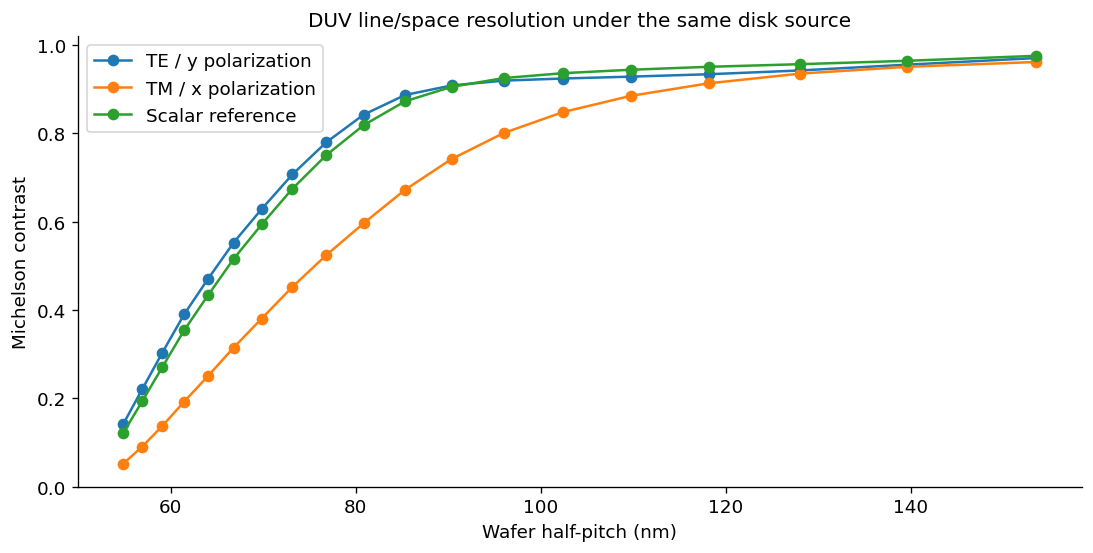

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")

for label, tf in [
    ("TE / y polarization", ty),
    ("TM / x polarization", transfer),
    ("Scalar reference", scalar),
]:
    contrast = [grating_contrast(int(p), tf, sources) for p in period_counts]
    ax.plot(half_pitches * 1e3, contrast, "o-", label=label)

ax.set(
    xlabel="Wafer half-pitch (nm)",
    ylabel="Michelson contrast",
    ylim=(0, 1.02),
    title="DUV line/space resolution under the same disk source",
)
ax.legend()
show(fig, "06_duv_te_tm_resolution")

**Next step:** Refine source and pixel sampling after the contrast curves.

In [16]:
finer_sources = disk_sources(0.6 * na / wavelength * count * pixel, step=1)
probe_periods = [24, 36, 48]
changes = [
    abs(
        grating_contrast(p, transfer, sources)
        - grating_contrast(p, transfer, finer_sources)
    )
    for p in probe_periods
]
print(
    f"Source refinement {len(sources)} → {len(finer_sources)} points: max contrast change {max(changes):.4f}"
)
# Refine image-plane pixels at fixed period to check the PSF width.
f2 = np.fft.fftfreq(2 * count, d=pixel / 2)
FX2, FY2 = np.meshgrid(f2, f2)
t2, _, _ = pupil_transfer(
    FX2, FY2, wavelength=wavelength, na=na, index=index, wavefront=wavefront
)
e2 = np.fft.fftshift(np.fft.ifft2(t2, axes=(0, 1)), axes=(0, 1))
x2 = (np.arange(2 * count) - count) * pixel / 2
w2 = fwhm(x2 * 1e3, np.sum(abs(e2[count]) ** 2, axis=-1))

# Compare pixel refinement after the source calculation.
print(f"12 → 6 nm pixels: x-FWHM {fwhm(x * 1e3, intensity[mid]):.3f} → {w2:.3f} nm")

Source refinement 421 → 1649 points: max contrast change 0.0049
12 → 6 nm pixels: x-FWHM 95.533 → 95.535 nm


## 6. Distinguish pupil quadrature from focal-pixel resolution

Doubling the period at fixed pixel size halves the pupil-frequency spacing.
This is a different control from halving image pixels at fixed period. The
Airy curve below is an independent scalar, unaberrated circular-pupil reference;
the aberrated vector x/y profiles need not equal it at high NA.

In [17]:
# Check focal profiles against aperture and period refinements.

from scipy.special import j1

f3 = np.fft.fftfreq(2 * count, d=pixel)
F3X, F3Y = np.meshgrid(f3, f3)
t3, _, _ = pupil_transfer(
    F3X, F3Y, wavelength=wavelength, na=na, index=index, wavefront=wavefront
)
e3 = np.fft.fftshift(np.fft.ifft2(t3, axes=(0, 1)), axes=(0, 1))
x3 = (np.arange(2 * count) - count) * pixel
width3 = fwhm(x3 * 1e3, np.sum(abs(e3[count]) ** 2, axis=-1))
width1 = fwhm(x * 1e3, intensity[mid])
print(f"6.144 → 12.288 µm period: x-FWHM {width1:.3f} → {width3:.3f} nm")
arg = 2 * np.pi * na * focal_axis / wavelength
airy = np.ones_like(arg)
nonzero = arg != 0
airy[nonzero] = (2 * j1(arg[nonzero]) / arg[nonzero]) ** 2

6.144 → 12.288 µm period: x-FWHM 95.533 → 95.561 nm


**Read the result:** Use refined radial and focal profiles as numerical controls.

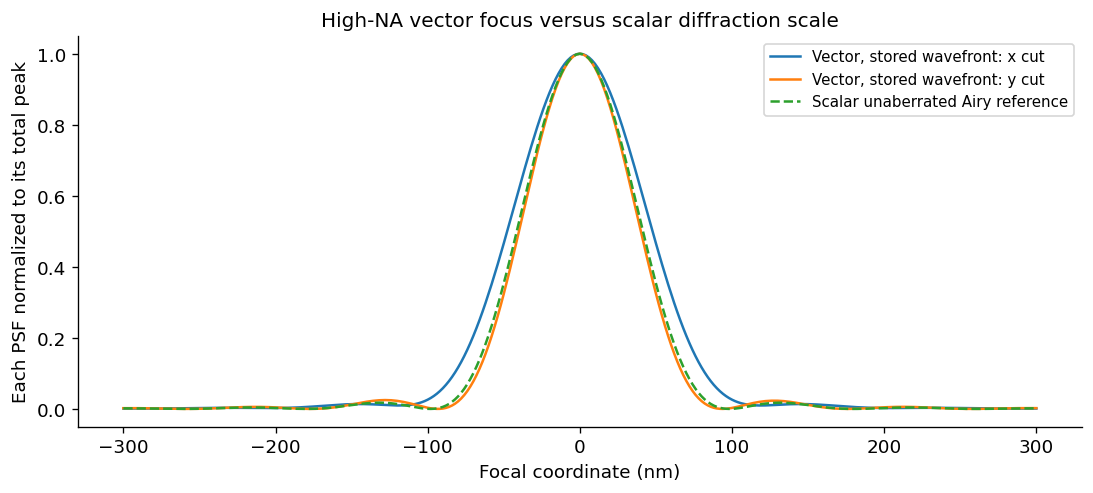

In [18]:
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
fm = len(focal_axis) // 2
ax.plot(
    focal_axis * 1e3,
    focal_norm[fm] / focal_norm.max(),
    label="Vector, stored wavefront: x cut",
)
ax.plot(
    focal_axis * 1e3,
    focal_norm[:, fm] / focal_norm.max(),
    label="Vector, stored wavefront: y cut",
)
ax.plot(focal_axis * 1e3, airy, "--", label="Scalar unaberrated Airy reference")
ax.set(
    xlabel="Focal coordinate (nm)",
    ylabel="Each PSF normalized to its total peak",
    title="High-NA vector focus versus scalar diffraction scale",
)
ax.legend(fontsize=9)
show(fig, "06_duv_focal_profiles")

**What is now available:** a real-system pupil dataset leads to a vector focal
field, through-focus maps, a circuit aerial image, TE/TM resolution curves and
sampling checks. The calculation remains a clearly separated reference model.
The still-missing full main-method path must transport the field through the
folded prescription, apertures and reflections and reproduce an independently
validated exit pupil before this notebook can become its validation result.